
# Deep Operator Network (DeepONets) in Neuromancer: Learning nonlinear operators

This tutorial demonstrates the use of Deep Operator Network (DeepONets) for solving partial differential equations (PDEs) in the Neuromancer library.

Example inspiration: https://neuraloperator.github.io/dev/auto_examples/models/plot_FNO_darcy.html

<img src="https://media.springernature.com/lw685/springer-static/image/art%3A10.1038%2Fs42256-021-00302-5/MediaObjects/42256_2021_302_Fig1_HTML.png" width="700">  


### References

[1] [Lu, L., Jin, P., Pang, G. et al. Learning nonlinear operators via DeepONet based on the universal approximation theorem of operators. Nat Mach Intell 3, 218–229 (2021).](https://www.nature.com/articles/s42256-021-00302-5)

[2] https://github.com/jdtoscano94/Learning-Python-Physics-Informed-Machine-Learning-PINNs-DeepONets/tree/main

[3] [Lu, L., Meng, X., Cai, S., Mao, Z., Goswami, S., Zhang, Z., & Karniadakis, G. E. (2022). A comprehensive and fair comparison of two neural operators (with practical extensions) based on fair data. Computer Methods in Applied Mechanics and Engineering, 393, 114778.](https://www.sciencedirect.com/science/article/pii/S0045782522001207?via%3Dihub)

[4] https://docs.nvidia.com/physicsnemo/25.08/physicsnemo-sym/user_guide/neural_operators/deeponet.html

## Install (Colab only)
Skip this step when running locally.

In [1]:
# !pip install neuromancer
# !pip install pyDOE

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

## Imports

In [1]:
# torch and numpy imports
import torch
import torch.nn as nn
import numpy as np

# plotting imports
import matplotlib.pyplot as plt

# filter some user warnings from torch broadcast
import warnings

warnings.filterwarnings("ignore")


In [2]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)
# PyTorch random number generator
torch.manual_seed(1234)

# Random number generators in other libraries
np.random.seed(1234)

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


In [ ]:
# import os

# os.environ["CUDA_VISIBLE_DEVICES"] = ""  # hide GPUs
# device = torch.device("cpu")
# torch.manual_seed(1234)
# np.random.seed(1234)

# print(f"Using device: {device}")


Using device: cpu


### Get data of the exact solution
- Data source: (https://zenodo.org/records/12784353)
- Select the number of training grids (`n_train`) at a given resolution (`train_resolution`) (16X16)
- Select the number of testing grids (`n_tests`) at various resolutions (`test_resolutions`) (16X16, 32x32)
- Download if needed, save it in `./data/darcy_flow_small/`

In [3]:
from neuralop.data.datasets import DarcyDataset

dataset = DarcyDataset(
    root_dir="./data/darcy_flow_small/",
    n_train=20,
    n_tests=[10, 10],
    batch_size=4,
    test_batch_sizes=[4, 2],
    train_resolution=16,
    test_resolutions=[16, 32],
    download=True,
)

print(dataset.__dict__.keys())  # check available keys in dataset

Loading test db for resolution 16 with 10 samples 
Loading test db for resolution 32 with 10 samples 
dict_keys(['root_dir', 'batch_size', 'test_resolutions', 'test_batch_sizes', '_train_db', '_data_processor', '_test_dbs'])


Displaying sizes for the 16x16 testing grid

In [4]:
train_db = dataset._train_db
print((train_db.__dict__.keys()))  # check available keys in dataset
# Get dataset length and grid resolution
n_train = len(train_db)
index = 0
x_sample = train_db[index]["x"]  # shape (1, 16, 16) for one snapshot of data
res_x, res_y = x_sample.shape[-2:]  # grid resolution

print(f"length of training set = {n_train}")
print(f"resolution = {res_x}")
print(f"shape of grid = [{res_x}, {res_y}]")


dict_keys(['x', 'y', 'transform_x', 'transform_y'])
length of training set = 20
resolution = 16
shape of grid = [16, 16]


Displaying sizes for the 32x32 testing grid

In [5]:
test_db = dataset._test_dbs[16]  # use 16,32 etc
print((test_db.__dict__.keys()))  # check available keys in dataset
# Get dataset length and grid resolution
n_train = len(test_db)

index = 0
x_sample = test_db[index]["x"]  # shape (1, 16, 16) for your data
res_x, res_y = x_sample.shape[-2:]  # grid resolution

print(f"length of training set = {n_train}")
print(f"resolution = {res_x}")
print(f"shape of grid = [{res_x}, {res_y}]")

dict_keys(['x', 'y', 'transform_x', 'transform_y'])
length of training set = 10
resolution = 16
shape of grid = [16, 16]


### Visualise dataset
We can see how the positional embedding adds coordinate information to our input data. This helps the neural operator understand spatial relationships in the data.
Not necessarly need to use this for the input grid

In [6]:
from neuralop.layers.embeddings import GridEmbedding2D

# Which sample to view
index = 0

data = train_db[index]
data = dataset.data_processor.preprocess(data, batched=False)

# The first step of the default FNO model is a grid-based
# positional embedding. We will add it manually here to
# visualize the channels appended by this embedding.
positional_embedding = GridEmbedding2D(in_channels=1)
# At train time, data will be collated with a batch dimension.
# We create a batch dimension to pass into the embedding, then re-squeeze
x = positional_embedding(data["x"].unsqueeze(0)).squeeze(0)
y = data["y"]

/tmp/ipykernel_772875/2254824060.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


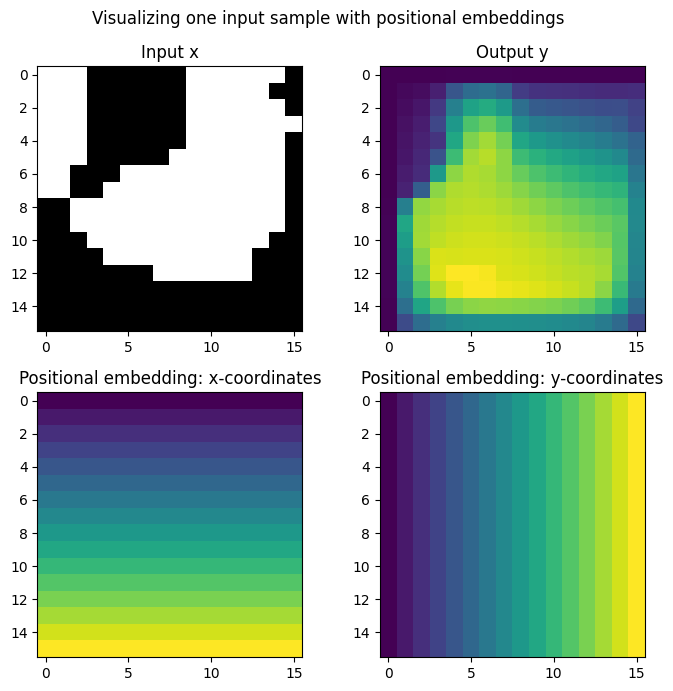

In [7]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(2, 2, 1)
ax.imshow(x[0], cmap="gray")
ax.set_title("Input x")
ax = fig.add_subplot(2, 2, 2)
ax.imshow(y.squeeze())
ax.set_title("Output y")
ax = fig.add_subplot(2, 2, 3)
ax.imshow(x[1])
ax.set_title("Positional embedding: x-coordinates")
ax = fig.add_subplot(2, 2, 4)
ax.imshow(x[2])
ax.set_title("Positional embedding: y-coordinates")
fig.suptitle("Visualizing one input sample with positional embeddings", y=0.98)
plt.tight_layout()
fig.show()

### Create Neuromancer datasets for DeepONet

In [8]:
from neuromancer.dataset import DictDataset

dim_x = 1

# positional_embedding = GridEmbedding2D(in_channels=dim_x).to(device)
positional_embedding = GridEmbedding2D(in_channels=dim_x).to(device)

xs, ys = [], []
for i in range(len(dataset._train_db)):
    s = dataset.data_processor.preprocess(dataset._train_db[i], batched=False)
    xs.append(s["x"])  # (1, H, W)
    ys.append(s["y"].squeeze(0))  # (H, W)
x_train = torch.stack(xs)  # [N, 1, 16, 16]
y_train = torch.stack(ys)  # [N, 1, H, W]

# send to device
x_train = x_train.to(device)
y_train = y_train.to(device)

# turn on gradients for training DeepONet
x_train.requires_grad = True
y_train.requires_grad = True

print(x_train.shape)

N, _, H, W = x_train.shape
m = H * W
d = dim_x

# coordinates from one exemplar; keep only one channel for dim_x=1
emb = positional_embedding(x_train[0:1]).squeeze(0)  # (3, H, W)
coords = emb[1].reshape(m, d)  # (m, dim_x)

branch = x_train.squeeze(1).reshape(N, m)  # (N, m)
trunk = coords.unsqueeze(0).expand(N, -1, -1)  # (N, m, 1)
outputs = y_train.reshape(N, m)  # (N, m)

train_ds = DictDataset(
    {"branch_inputs": branch, "trunk_inputs": trunk, "outputs": outputs},
    name="train",
)


torch.Size([20, 1, 16, 16])


In [9]:
print(len(dataset.test_dbs[16]))

10


In [10]:
# Example test loader (pick one resolution index)
res = 16  # 16 or 32
batch_size_test = 4
xs_t, ys_t = [], []

for i in range(len(dataset.test_dbs[res])):
    s = dataset.data_processor.preprocess(dataset.test_dbs[res][i], batched=False)
    xs_t.append(s["x"])  # (1, H, W)
    ys_t.append(s["y"].squeeze(0))  # (H, W)
x_test = torch.stack(xs_t)  # (N, 1, H, W)
y_test = torch.stack(ys_t)  # (N, H, W)

# send to device
x_test = x_test.to(device)
y_test = y_test.to(device)

print(x_test.shape)

N, _, H, W = x_test.shape
m = H * W
d = dim_x

# coordinates from one exemplar; keep only one channel for dim_x=1
emb = positional_embedding(x_test[0:1]).squeeze(0)  # (3, H, W)
coords = emb[1].reshape(m, d)  # (m, dim_x)

branch = x_test.squeeze(1).reshape(N, m)  # (N, m)
trunk = coords.unsqueeze(0).expand(N, -1, -1)  # (N, m, 1)
outputs = y_test.reshape(N, m)  # (N, m)

test_ds = DictDataset(
    {"branch_inputs": branch, "trunk_inputs": trunk, "outputs": outputs},
    name=f"test{res}",
)


torch.Size([10, 1, 16, 16])


In [13]:
# check device for train data
print(train_ds.datadict["branch_inputs"].device)
print(train_ds.datadict["trunk_inputs"].device)
print(test_ds.datadict["branch_inputs"].device)
print(test_ds.datadict["trunk_inputs"].device)
# Check shapes match (Input vs Forward Pass Output)
print(f"Input branch shape: {train_ds.datadict['branch_inputs'].shape}")
print(f"Input trunk shape: {train_ds.datadict['trunk_inputs'].shape}")
# Check shapes match (Input vs Forward Pass Output)
print(f"Input branch shape: {test_ds.datadict['branch_inputs'].shape}")
print(f"Input trunk shape: {test_ds.datadict['trunk_inputs'].shape}")


cuda:0
cuda:0
cuda:0
cuda:0
Input branch shape: torch.Size([20, 256])
Input trunk shape: torch.Size([20, 256, 1])
Input branch shape: torch.Size([10, 256])
Input trunk shape: torch.Size([10, 256, 1])


In [14]:
batch_size_train = 4
batch_size_test = 2

train_loader = torch.utils.data.DataLoader(
    train_ds,
    batch_size=batch_size_train,
    shuffle=True,
    collate_fn=train_ds.collate_fn,
)

test_loader = torch.utils.data.DataLoader(
    test_ds,
    batch_size=batch_size_test,
    shuffle=True,
    collate_fn=test_ds.collate_fn,
)

## Dimensionality checks for data

In [15]:
s = dataset.data_processor.preprocess(dataset.test_dbs[res][0], batched=False)
print(s["x"].shape, s["y"].shape)

torch.Size([1, 16, 16]) torch.Size([1, 1, 16, 16])


In [16]:
s = dataset.data_processor.preprocess(dataset._train_db[0], batched=False)
print(s["x"].shape, s["y"].shape)

torch.Size([1, 16, 16]) torch.Size([1, 1, 16, 16])


# Define DeepONet

The branch net is chosen as a fully connected neural network of size `[m, 32, p]`, where `p=32` and the trunk net is a fully connected neural network of size `[dim_x, 32, p]`, where `dim_x` is dimension i.e. 1

We use `dde.nn.DeepONet` to create the DeepONet directly for DeepXDE library. This is a generic DeepONet implementation needing a list of triple (function_sample, location, target_value)
(MLP architecture the same as [DeepXDE Poisson 1D example](https://deepxde.readthedocs.io/en/latest/demos/operator/poisson.1d.pideeponet.html))

In [17]:
# DeepXDE library
import os

os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde

# train_ds
sample = train_ds[0]
Nu = sample["branch_inputs"].shape[-1]  # numnber of sensors
dim_x = sample["trunk_inputs"].shape[-1]  # 1

print(Nu, dim_x)

p = 32
dde_DeepOnet = dde.nn.DeepONetCartesianProd(
    [Nu, 32, p],
    [dim_x, 32, p],
    activation="tanh",
    kernel_initializer="Glorot normal",
)


Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


256 1


In [18]:
from neuromancer.system import Node
from neuromancer.modules.operators import DeepXDEWrapper

dde_DeepOnet_wrapped = DeepXDEWrapper(
    model=dde_DeepOnet,
    is_cartesian=True,
)

node_dde_deeponet = Node(
    dde_DeepOnet_wrapped,
    ["branch_inputs", "trunk_inputs"],
    ["g"],
    name="dde_DeepOnet",
)
print(node_dde_deeponet)

dde_DeepOnet(branch_inputs, trunk_inputs) -> g


In [19]:
print("symbolic inputs  of the fno_node:", node_dde_deeponet.input_keys)
print("symbolic outputs of the fno_node:", node_dde_deeponet.output_keys)

symbolic inputs  of the fno_node: ['branch_inputs', 'trunk_inputs']
symbolic outputs of the fno_node: ['g']


In [20]:
# check device for train data
print(train_ds.datadict["branch_inputs"].device)
print(train_ds.datadict["trunk_inputs"].device)
# Check shapes match (Input vs Forward Pass Output)
print(f"Input branch shape: {train_ds.datadict['branch_inputs'].shape}")
print(f"Input trunk shape: {train_ds.datadict['trunk_inputs'].shape}")


cuda:0
cuda:0
Input branch shape: torch.Size([20, 256])
Input trunk shape: torch.Size([20, 256, 1])


In [21]:
# Forward pass
sample = train_ds[0]
print(sample.keys())

# add batch dim to every tensor value in sample so you can feed the model a single-sample batch
# sample = {k: v.unsqueeze(0).to(device) for k, v in sample.items()}
sample = {k: v.unsqueeze(0) for k, v in sample.items()}

print(sample["branch_inputs"].shape)
print(sample["trunk_inputs"].shape)

node_out = node_dde_deeponet(sample)
print(f"Output shape: {node_out['g'].shape}")


dict_keys(['branch_inputs', 'trunk_inputs', 'outputs'])
torch.Size([1, 256])
torch.Size([1, 256, 1])
Output shape: torch.Size([1, 256])


# Generate H1 and L2 loss for loss evaluation 
We use H1 loss for training and L2 loss for evaluation H1 loss is particularly good for PDE problems as it penalizes both function values and gradients

## L2 norm

$$
\|y - y_h\|_{L^2(\Omega)}^2.
$$

## H1 norm

$$
\|y - y_h\|_{H^1(\Omega)}^2
=
\|y - y_h\|_{L^2(\Omega)}^2
+
\|y_x - y_{h,x}\|_{L^2(\Omega)}^2
+
\|y_t - y_{h,t}\|_{L^2(\Omega)}^2.
$$

### Formulate L2 loss, H1 loss

Approach 1: Use a standard H1 loss python function and wrap it in the `neuromancer.constraint.Loss` object

In [22]:
from neuromancer.modules.operators import LpLoss, H1Loss
from neuromancer.constraint import Loss  # wrapper for neuromancer

h1_loss_fn = H1Loss(d=1)
l2_loss_fn = LpLoss(d=1, p=2)

h1_obj = Loss(
    ["g", "outputs"],
    lambda yhat, y: h1_loss_fn(yhat.squeeze(1), y.squeeze(1)),
    name="h1_loss_fn",
)

l2_obj = Loss(
    ["g", "outputs"],
    lambda yhat, y: l2_loss_fn(yhat.squeeze(1), y.squeeze(1)),
    name="l2_loss_fn",
)

Approach 2: Formulate the H1 loss definition with simple Neuromancer wrappers

In [22]:
from neuromancer.constraint import variable

# Inputs from your datadict
y_true = variable("g")  # B x C x H x W
y_hat_fno = variable("outputs")  # B x C x H x W

# Finite forward differences
dx_hat = (
    y_hat_fno[..., 1:, :] - y_hat_fno[..., :-1, :]
)  # \hat{f}{x_{i+1},y_i} - \hat{f}_{x_i,y_i}
dx_true = y_true[..., 1:, :] - y_true[..., :-1, :]  # f(x_{i+1},y_i} - f_{x_i,y_i}

dy_hat = (
    y_hat_fno[..., :, 1:] - y_hat_fno[..., :, :-1]
)  # \hat{f}{x_i,y_{i+1}} - \hat{f}_{x_i,y_i}
dy_true = y_true[..., :, 1:] - y_true[..., :, :-1]  # f{x_i,y_{i+1}) - f_{x_i,y_i}

Apply constraints on `variable` 

In [23]:
# Value (L2) match and gradient (L2) matches; ^2 sets the L2 norm
val_constraint = (y_hat_fno == y_true) ^ 2
val_constraint.update_name("h1_value")

x_grad_constraint = (dx_hat == dx_true) ^ 2
x_grad_constraint.update_name("h1_dx")

y_grad_constraint = (dy_hat == dy_true) ^ 2
y_grad_constraint.update_name("h1_dy")

# To do: add weights, normalisation of gradient losses

Approach 3: Wrap the residuals with `Objective` and minimise 

In [24]:
from neuromancer.constraint import Objective

# Approach 2: Using Objective
residual_l2 = y_hat_fno - y_true
l2_obj = Objective(residual_l2**2, metric=torch.mean, name="l2_loss")

# Approach 2: Using Objective
residual_h1_dx = dx_hat - dx_true
h1_dx_obj = Objective(residual_h1_dx**2, metric=torch.mean, name="h1_dx_loss")

# Approach 2: Using Objective
residual_h1_dy = dy_hat - dy_true
h1_dy_obj = Objective(residual_h1_dy**2, metric=torch.mean, name="h1_dy_loss")

### Setup FNO problem and Trainer 

In [25]:
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem

# aggregate list of objective terms and constraints
# H1 loss (h1_obj) or L2 loss (l2_obj) for training FNO
objectives_fno = [l2_obj]  # Approach 1
# objectives_fno = [val_constraint, x_grad_constraint, y_grad_constraint] #Approach 2
# objectives_fno = [l2_obj, h1_dx_obj, h1_dy_obj]  # Approach 3
constraints_fno = []
# create constrained optimization loss
loss_fno = PenaltyLoss(objectives_fno, constraints_fno)

# construct the FNO supervised training problem
problem = Problem(nodes=[node_dde_deeponet], loss=loss_fno)

### Show problem FNO

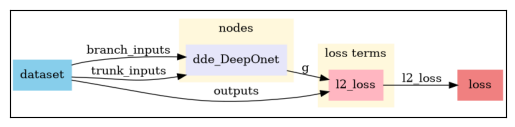

In [26]:
# Visualize the problem graph. Note: must have graphviz installed in the system
problem.show()

In [27]:
print(device)

cuda


### Train FNO purely data driven - using 20 samples of 16 x 16 data

In [28]:
from neuromancer.trainer import Trainer

optimizer = torch.optim.AdamW(problem.parameters(), lr=1e-2, weight_decay=1e-4)
epochs = 50

#  Neuromancer trainer
trainer = Trainer(
    problem.to(device),
    train_loader,
    optimizer=optimizer,
    epochs=epochs,
    epoch_verbose=10,
    train_metric="train_loss",
    dev_metric="train_loss",
    eval_metric="train_loss",
    warmup=epochs,
    device=device,
)

In [29]:
print(device)

cuda


In [30]:
# Train DeepONet
best_model = trainer.train()

# load best trained model
# best_model = {k: v.to(device) for k, v in best_model.items()}
problem.load_state_dict(best_model)

RuntimeError: Expected a 'cuda' device type for generator but found 'cpu'

## Visualizing predictions

### Zero-shot super-resolution evaluation
One of the key advantages of neural operators is their resolution invariance. We can test on 32 x 32 grid directly from a 16x16 training of the FNO

In [31]:
# evaluate trained FNO on test data
fno_out = problem.nodes[0].cpu()
fno_model_out = fno_out(test_ds.datadict)  # now on 32x32 grid

# evaluate forward pass on the train data
print(f"Output shape: {fno_model_out['g'].shape}")


Output shape: torch.Size([10, 256])


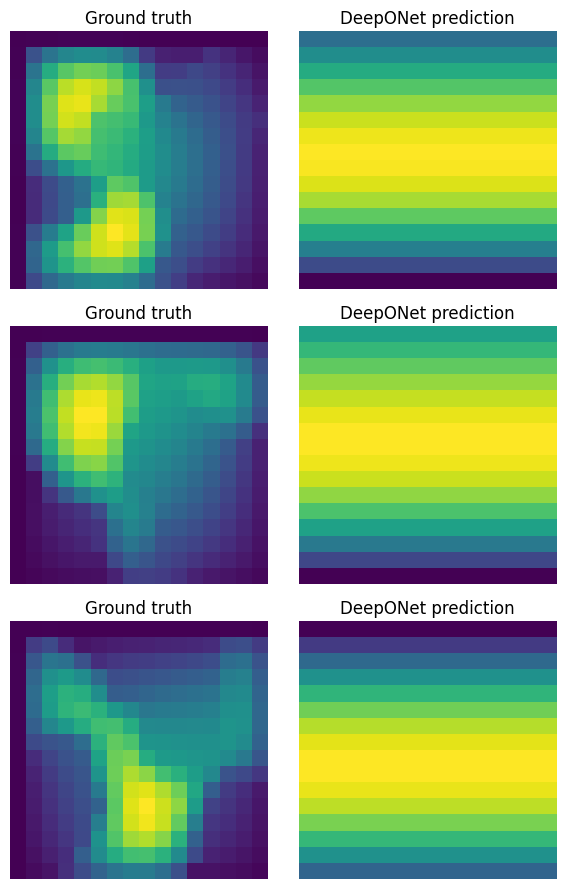

In [ ]:
# evaluate trained DeepONet on test data and visualize a few samples
fno_out = problem.nodes[0].cpu()
with torch.no_grad():
    fno_model_out = fno_out(test_ds.datadict)

preds = fno_model_out["g"].cpu()  # [N, 256]
truth = test_ds.datadict["outputs"].cpu()  # [N, 256]

m = preds.shape[1]
H = W = int(m**0.5)  # 256 -> 16 x 16

fig, axs = plt.subplots(3, 2, figsize=(6, 9))
for i in range(3):
    axs[i, 0].imshow(truth[i].reshape(H, W), cmap="viridis")
    axs[i, 0].set_title("Ground truth")
    axs[i, 0].axis("off")

    axs[i, 1].imshow(preds[i].reshape(H, W), cmap="viridis")
    axs[i, 1].set_title("DeepONet prediction")
    axs[i, 1].axis("off")

plt.tight_layout()
plt.show()


In [33]:
# Get predictions from the trained FNO on the stacked test set
fno_eval = problem.nodes[0].cpu()  # ensure model on CPU for plotting
with torch.no_grad():
    preds = fno_eval(test_ds.datadict)["g"].cpu()

fig = plt.figure(figsize=(7, 7))
for index in range(3):
    sample = test_ds[index]  # {'x_grid': ..., 'y_grid': ...}
    x = sample["x_grid"].cpu()
    y = sample["y_grid"].cpu()
    out = preds[index]  # model output from problem_fno

    ax = fig.add_subplot(3, 3, index * 3 + 1)
    ax.imshow(x[0], cmap="gray")
    if index == 0:
        ax.set_title("Input x")
    plt.xticks([], [])
    plt.yticks([], [])

    ax = fig.add_subplot(3, 3, index * 3 + 2)
    ax.imshow(y.squeeze())
    if index == 0:
        ax.set_title("Ground-truth output")
    plt.xticks([], [])
    plt.yticks([], [])

    ax = fig.add_subplot(3, 3, index * 3 + 3)
    ax.imshow(out.squeeze().detach().numpy())
    if index == 0:
        ax.set_title("Model prediction")
    plt.xticks([], [])
    plt.yticks([], [])

fig.suptitle("FNO predictions on test Darcy-Flow data", y=0.98)
plt.tight_layout()
fig.show()


KeyError: 'x_grid'

<Figure size 700x700 with 0 Axes>

### Testing on 16 x 16 dataset

In [ ]:
# Example test loader (pick one resolution index)
res = 16  # 16 or 32
batch_size_test = 4
xs_t, ys_t = [], []
for i in range(len(dataset.test_dbs[res])):
    sample = dataset.data_processor.preprocess(dataset.test_dbs[res][i], batched=False)
    xs_t.append(sample["x"])
    ys_t.append(sample["y"].squeeze(0))  # [1, H, W]

x_test = torch.stack(xs_t)  # [N, 1, 16, 16]
y_test = torch.stack(ys_t)  # [N, 1, H, W]

test_ds_fno = DictDataset({"x_grid": x_test, "y_grid": y_test}, name=f"test{res}")
test_loader_fno = torch.utils.data.DataLoader(
    test_ds_fno,
    batch_size=batch_size_test,  # match your test batch size
    shuffle=False,
    collate_fn=test_ds_fno.collate_fn,
)

In [ ]:
# evaluate trained FNO on test data
fno_out = problem_fno.nodes[0].cpu()
fno_model_out = fno_out(test_ds_fno.datadict)  # now on 32x32 grid

# evaluate forward pass on the train data
fno_model_out["y_fno"].shape

torch.Size([10, 1, 16, 16])

/tmp/ipykernel_642658/3574052000.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


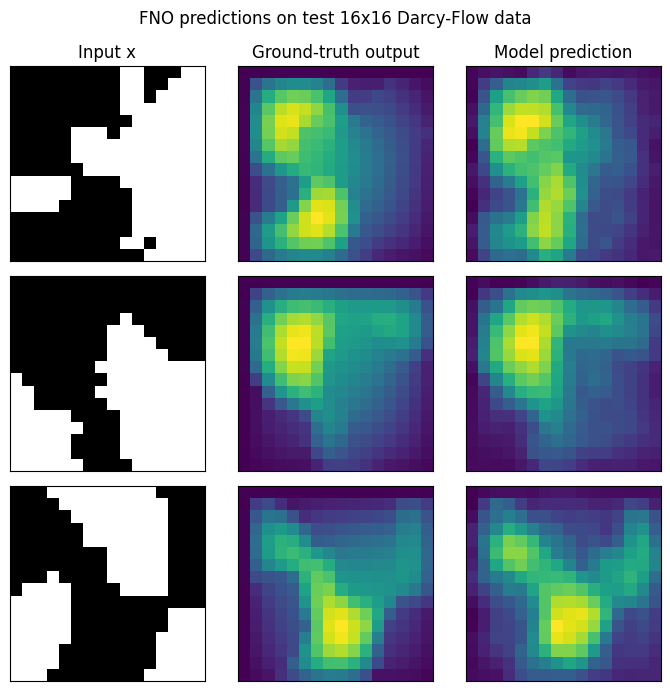

In [ ]:
# Get predictions from the trained FNO on the stacked test set
fno_eval = problem_fno.nodes[0].cpu()  # ensure model on CPU for plotting
with torch.no_grad():
    preds = fno_eval(test_ds_fno.datadict)["y_fno"].cpu()

fig = plt.figure(figsize=(7, 7))
for index in range(3):
    sample = test_ds_fno[index]  # {'x_grid': ..., 'y_grid': ...}
    x = sample["x_grid"].cpu()
    y = sample["y_grid"].cpu()
    out = preds[index]  # model output from problem_fno

    ax = fig.add_subplot(3, 3, index * 3 + 1)
    ax.imshow(x[0], cmap="gray")
    if index == 0:
        ax.set_title("Input x")
    plt.xticks([], [])
    plt.yticks([], [])

    ax = fig.add_subplot(3, 3, index * 3 + 2)
    ax.imshow(y.squeeze())
    if index == 0:
        ax.set_title("Ground-truth output")
    plt.xticks([], [])
    plt.yticks([], [])

    ax = fig.add_subplot(3, 3, index * 3 + 3)
    ax.imshow(out.squeeze().detach().numpy())
    if index == 0:
        ax.set_title("Model prediction")
    plt.xticks([], [])
    plt.yticks([], [])

fig.suptitle("FNO predictions on test 16x16 Darcy-Flow data", y=0.98)
plt.tight_layout()
fig.show()
